# Notebook 14 — Simple Neural Network

## Leadership and Management Book Recommendation System

### Objective

This notebook develops a simple neural network using **PyTorch** and the validated numerical book representations prepared in the previous stage.

The project is primarily an **unsupervised, content-based recommendation system** and does not contain a genuine supervised target variable.

Therefore, rather than creating artificial classification or regression labels, this notebook implements a **feed-forward autoencoder**.

An autoencoder learns to reconstruct its input through a smaller latent representation:

**200-dimensional LSA Input → Encoder → Latent Representation → Decoder → 200-dimensional Reconstruction**

### Purpose

The neural network is used to investigate whether the existing 200-dimensional semantic book representation can be compressed into a smaller learned representation while retaining sufficient information to reconstruct the original features.

This provides a methodologically appropriate neural-network experiment for the existing unsupervised project.

### Input

The model uses the validated PyTorch artifact created in Notebook 13:

`models/enriched_lsa_200_tensor.pt`

The tensor contains:

- **2,067 books**
- **200 LSA features per book**
- `float32` numerical values
- 27 preserved zero-vector books

The corresponding book-index mapping is stored in:

`data/processed/pytorch_tensor_book_index.csv`

### Neural Network Architecture

The initial autoencoder architecture will follow:

**Input (200) → Hidden Layer → Latent Layer → Hidden Layer → Output (200)**

The encoder reduces dimensionality, while the decoder attempts to reconstruct the original LSA vector.

The network will use a reconstruction loss rather than a classification or regression target.

### Evaluation

The neural network will be evaluated using measures appropriate for an autoencoder, including:

- training reconstruction loss;
- validation reconstruction loss;
- reconstruction error;
- comparison between original and reconstructed vectors;
- preservation of semantic similarity where appropriate.

The model will not be evaluated using classification accuracy, precision, recall, or F1-score because no genuine class target exists.

### Methodological Position

The autoencoder is an experimental neural representation-learning component.

It does **not automatically replace** the validated recommendation engine from Notebook 12.

The primary recommendation architecture remains:

**Enriched TF-IDF → Cosine Similarity → Duplicate Suppression → Ranked Top-N Recommendations**

The neural-network representation will only be considered useful if evaluation demonstrates that it preserves meaningful information from the existing semantic feature space.

In [1]:
# ============================================================
# NOTEBOOK 14 — SIMPLE NEURAL NETWORK
# ENVIRONMENT AND ARTIFACT CHECK
# ============================================================

from pathlib import Path
import sys

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


# ------------------------------------------------------------
# Project directories
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/Users/jannoelvero/Documents/Ironhack/Week_11/"
    "Leadership_Management_Book_Recommendation_System"
)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"


# ------------------------------------------------------------
# Required artifacts
# ------------------------------------------------------------

TENSOR_PATH = (
    MODELS_DIR
    / "enriched_lsa_200_tensor.pt"
)

TENSOR_INDEX_PATH = (
    PROCESSED_DIR
    / "pytorch_tensor_book_index.csv"
)


# ------------------------------------------------------------
# Environment validation
# ------------------------------------------------------------

print("NEURAL NETWORK — ENVIRONMENT CHECK")
print("=" * 80)

print("Python version:")
print(sys.version)

print("\nPyTorch version:")
print(torch.__version__)

print(
    "\nMPS available:",
    torch.backends.mps.is_available()
)

print(
    "\nTensor artifact exists:",
    TENSOR_PATH.exists()
)

print(
    "Tensor index exists:",
    TENSOR_INDEX_PATH.exists()
)

print("\nTensor path:")
print(TENSOR_PATH)

print("\nIndex path:")
print(TENSOR_INDEX_PATH)

NEURAL NETWORK — ENVIRONMENT CHECK
Python version:
3.13.11 | packaged by Anaconda, Inc. | (main, Dec 10 2025, 21:21:08) [Clang 20.1.8 ]

PyTorch version:
2.14.0

MPS available: True

Tensor artifact exists: True
Tensor index exists: True

Tensor path:
/Users/jannoelvero/Documents/Ironhack/Week_11/Leadership_Management_Book_Recommendation_System/models/enriched_lsa_200_tensor.pt

Index path:
/Users/jannoelvero/Documents/Ironhack/Week_11/Leadership_Management_Book_Recommendation_System/data/processed/pytorch_tensor_book_index.csv


## 1. Load and Prepare Neural Network Data

The validated PyTorch tensor and its corresponding book index are reloaded from Notebook 13.

The complete tensor contains **2,067 books**, including **27 zero-vector books**.

For neural-network training, the zero-vector observations are excluded because they contain no usable semantic features. Including them would introduce trivial all-zero reconstruction examples that do not contribute meaningful information to representation learning.

This exclusion applies only to the neural-network modelling population.

The original catalog and canonical tensor remain unchanged:

- Complete catalog: **2,067 books**
- Zero-vector books: **27**
- Neural-network eligible books: **2,040**

The book identifiers are preserved separately so that every learned representation can later be mapped back to the correct book.

In [2]:
# ============================================================
# LOAD AND PREPARE NEURAL NETWORK DATA
# ============================================================

# Load validated Notebook 13 artifacts
full_feature_tensor = torch.load(
    TENSOR_PATH,
    map_location="cpu"
)

tensor_index = pd.read_csv(
    TENSOR_INDEX_PATH
)


# ------------------------------------------------------------
# Validate loaded artifacts
# ------------------------------------------------------------

print("NEURAL NETWORK DATA PREPARATION")
print("=" * 80)

print(
    "Full tensor shape:",
    full_feature_tensor.shape
)

print(
    "Tensor dtype:",
    full_feature_tensor.dtype
)

print(
    "Index rows:",
    len(tensor_index)
)

print(
    "Tensor/index aligned:",
    len(tensor_index) == full_feature_tensor.shape[0]
)


# ------------------------------------------------------------
# Create zero-vector mask
# ------------------------------------------------------------

zero_mask = torch.tensor(
    tensor_index["is_zero_vector"]
    .astype(bool)
    .to_numpy(),
    dtype=torch.bool
)

print(
    "\nZero-vector books:",
    int(zero_mask.sum().item())
)


# ------------------------------------------------------------
# Create modelling population
# ------------------------------------------------------------

model_feature_tensor = full_feature_tensor[
    ~zero_mask
].clone()

model_book_ids = tensor_index.loc[
    ~tensor_index["is_zero_vector"].astype(bool),
    "book_id"
].reset_index(drop=True)


print(
    "Eligible modelling books:",
    model_feature_tensor.shape[0]
)

print(
    "Number of features:",
    model_feature_tensor.shape[1]
)


# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------

model_norms = torch.linalg.vector_norm(
    model_feature_tensor,
    dim=1
)

print(
    "\nAll modelling vectors non-zero:",
    bool(torch.all(model_norms > 0).item())
)

print(
    "NaN values:",
    bool(torch.isnan(model_feature_tensor).any().item())
)

print(
    "Infinite values:",
    bool(torch.isinf(model_feature_tensor).any().item())
)

print(
    "Book IDs aligned:",
    len(model_book_ids) == model_feature_tensor.shape[0]
)

print(
    "Unique modelling book IDs:",
    model_book_ids.nunique()
)

NEURAL NETWORK DATA PREPARATION
Full tensor shape: torch.Size([2067, 200])
Tensor dtype: torch.float32
Index rows: 2067
Tensor/index aligned: True

Zero-vector books: 27
Eligible modelling books: 2040
Number of features: 200

All modelling vectors non-zero: True
NaN values: False
Infinite values: False
Book IDs aligned: True
Unique modelling book IDs: 2040


## 2. Train, Validation, and Test Split

The 2,040 eligible book vectors are divided into three mutually exclusive datasets:

- **Training set — 70%:** used to optimize the autoencoder parameters;
- **Validation set — 15%:** used to monitor generalization during model development;
- **Test set — 15%:** reserved for final evaluation on unseen books.

A fixed random seed is used to make the split reproducible.

Because the autoencoder is an unsupervised reconstruction model, no target labels are required. Each input vector also serves as its reconstruction target during training.

The split is performed at the **book level**, ensuring that a book appears in only one partition.

The test set will not be used for model training or architecture selection.

In [3]:
# ============================================================
# TRAIN / VALIDATION / TEST SPLIT
# ============================================================

SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)


# ------------------------------------------------------------
# Generate reproducible shuffled indices
# ------------------------------------------------------------

n_books = model_feature_tensor.shape[0]

generator = torch.Generator().manual_seed(SEED)

shuffled_indices = torch.randperm(
    n_books,
    generator=generator
)


# ------------------------------------------------------------
# Define split sizes
# ------------------------------------------------------------

n_train = int(0.70 * n_books)
n_validation = int(0.15 * n_books)

n_test = (
    n_books
    - n_train
    - n_validation
)


train_indices = shuffled_indices[
    :n_train
]

validation_indices = shuffled_indices[
    n_train:n_train + n_validation
]

test_indices = shuffled_indices[
    n_train + n_validation:
]


# ------------------------------------------------------------
# Create feature tensors
# ------------------------------------------------------------

X_train = model_feature_tensor[
    train_indices
].clone()

X_validation = model_feature_tensor[
    validation_indices
].clone()

X_test = model_feature_tensor[
    test_indices
].clone()


# ------------------------------------------------------------
# Preserve corresponding book IDs
# ------------------------------------------------------------

train_book_ids = model_book_ids.iloc[
    train_indices.numpy()
].reset_index(drop=True)

validation_book_ids = model_book_ids.iloc[
    validation_indices.numpy()
].reset_index(drop=True)

test_book_ids = model_book_ids.iloc[
    test_indices.numpy()
].reset_index(drop=True)


# ------------------------------------------------------------
# Validate split
# ------------------------------------------------------------

print("TRAIN / VALIDATION / TEST SPLIT")
print("=" * 80)

print("Total eligible books:", n_books)

print(
    "\nTraining books:",
    len(X_train),
    f"({len(X_train) / n_books:.2%})"
)

print(
    "Validation books:",
    len(X_validation),
    f"({len(X_validation) / n_books:.2%})"
)

print(
    "Test books:",
    len(X_test),
    f"({len(X_test) / n_books:.2%})"
)

print(
    "\nTraining shape:",
    X_train.shape
)

print(
    "Validation shape:",
    X_validation.shape
)

print(
    "Test shape:",
    X_test.shape
)


# ------------------------------------------------------------
# Check partition integrity
# ------------------------------------------------------------

train_id_set = set(train_book_ids)
validation_id_set = set(validation_book_ids)
test_id_set = set(test_book_ids)

print(
    "\nTrain/validation overlap:",
    len(train_id_set & validation_id_set)
)

print(
    "Train/test overlap:",
    len(train_id_set & test_id_set)
)

print(
    "Validation/test overlap:",
    len(validation_id_set & test_id_set)
)

all_split_ids = (
    train_id_set
    | validation_id_set
    | test_id_set
)

print(
    "\nAll eligible books represented:",
    len(all_split_ids) == n_books
)

print(
    "Total unique books across splits:",
    len(all_split_ids)
)

TRAIN / VALIDATION / TEST SPLIT
Total eligible books: 2040

Training books: 1428 (70.00%)
Validation books: 306 (15.00%)
Test books: 306 (15.00%)

Training shape: torch.Size([1428, 200])
Validation shape: torch.Size([306, 200])
Test shape: torch.Size([306, 200])

Train/validation overlap: 0
Train/test overlap: 0
Validation/test overlap: 0

All eligible books represented: True
Total unique books across splits: 2040


## 3. Create Training, Validation, and Test DataLoaders

PyTorch `DataLoader` objects are created for the three modelling partitions.

For the autoencoder:

- the **training DataLoader** uses shuffled batches so that the model does not repeatedly encounter books in the same order;
- the **validation DataLoader** is not shuffled because it is used only for evaluation during model development;
- the **test DataLoader** is also not shuffled to preserve deterministic final evaluation.

A batch size of **32 books** is used.

Because an autoencoder reconstructs its own input, no separate target tensor is required. During training:

**Input = Original LSA Vector**

**Target = Original LSA Vector**

The test partition remains completely excluded from parameter optimization.

In [4]:
# ============================================================
# CREATE TRAIN / VALIDATION / TEST DATALOADERS
# ============================================================

BATCH_SIZE = 32


# ------------------------------------------------------------
# Create TensorDatasets
# ------------------------------------------------------------

train_dataset = TensorDataset(
    X_train
)

validation_dataset = TensorDataset(
    X_validation
)

test_dataset = TensorDataset(
    X_test
)


# ------------------------------------------------------------
# Create DataLoaders
# ------------------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED)
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ------------------------------------------------------------
# Validate DataLoaders
# ------------------------------------------------------------

print("AUTOENCODER DATALOADERS")
print("=" * 80)

print(
    "Training batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(validation_loader)
)

print(
    "Test batches:",
    len(test_loader)
)


# Retrieve one training batch
first_train_batch = next(
    iter(train_loader)
)[0]

print(
    "\nFirst training batch shape:",
    first_train_batch.shape
)

print(
    "Batch dtype:",
    first_train_batch.dtype
)

print(
    "Batch device:",
    first_train_batch.device
)

print(
    "NaN values:",
    bool(
        torch.isnan(
            first_train_batch
        ).any().item()
    )
)

print(
    "Infinite values:",
    bool(
        torch.isinf(
            first_train_batch
        ).any().item()
    )
)


# ------------------------------------------------------------
# Confirm dataset sizes
# ------------------------------------------------------------

print(
    "\nTraining observations:",
    len(train_dataset)
)

print(
    "Validation observations:",
    len(validation_dataset)
)

print(
    "Test observations:",
    len(test_dataset)
)

print(
    "Total observations:",
    (
        len(train_dataset)
        + len(validation_dataset)
        + len(test_dataset)
    )
)

AUTOENCODER DATALOADERS
Training batches: 45
Validation batches: 10
Test batches: 10

First training batch shape: torch.Size([32, 200])
Batch dtype: torch.float32
Batch device: cpu
NaN values: False
Infinite values: False

Training observations: 1428
Validation observations: 306
Test observations: 306
Total observations: 2040


## 4. Define the Autoencoder Architecture

A compact feed-forward autoencoder is used to learn a lower-dimensional representation of the 200-dimensional LSA book vectors.

The architecture is:

**Input (200) → 128 → 64 → Latent (32) → 64 → 128 → Output (200)**

### Encoder

The encoder progressively reduces the dimensionality:

- 200 input features;
- 128 hidden units;
- 64 hidden units;
- 32-dimensional latent representation.

### Decoder

The decoder mirrors the encoder:

- 32 latent features;
- 64 hidden units;
- 128 hidden units;
- 200 reconstructed features.

`ReLU` activation is used between hidden layers.

No activation function is applied to the final output layer because the original LSA features contain both positive and negative values. Restricting the output with functions such as `Sigmoid` or final-layer `ReLU` would therefore be inappropriate.

The 32-dimensional bottleneck represents a substantial compression from the original 200-dimensional LSA space.

The architecture is intentionally compact because the available neural-network training population contains 1,428 books. A substantially deeper network could introduce unnecessary model complexity relative to the dataset size.

In [5]:
# ============================================================
# DEFINE AUTOENCODER
# ============================================================

class BookAutoencoder(nn.Module):
    """
    Feed-forward autoencoder for 200-dimensional
    book LSA representations.
    """

    def __init__(
        self,
        input_dim=200,
        latent_dim=32
    ):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, latent_dim)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 128),
            nn.ReLU(),

            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)

        return reconstructed


# ------------------------------------------------------------
# Reproducible model initialization
# ------------------------------------------------------------

torch.manual_seed(SEED)

autoencoder = BookAutoencoder(
    input_dim=200,
    latent_dim=32
)


# ------------------------------------------------------------
# Device selection
# ------------------------------------------------------------

device = torch.device(
    "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

autoencoder = autoencoder.to(
    device
)


# ------------------------------------------------------------
# Model validation
# ------------------------------------------------------------

print("AUTOENCODER ARCHITECTURE")
print("=" * 80)

print(autoencoder)

print(
    "\nModel device:",
    next(autoencoder.parameters()).device
)


# Count parameters
total_parameters = sum(
    parameter.numel()
    for parameter in autoencoder.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in autoencoder.parameters()
    if parameter.requires_grad
)

print(
    "\nTotal parameters:",
    f"{total_parameters:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)


# ------------------------------------------------------------
# Test forward pass
# ------------------------------------------------------------

test_batch = first_train_batch.to(
    device
)

with torch.no_grad():

    reconstructed_batch = autoencoder(
        test_batch
    )

    latent_batch = autoencoder.encoder(
        test_batch
    )


print(
    "\nInput batch shape:",
    test_batch.shape
)

print(
    "Latent batch shape:",
    latent_batch.shape
)

print(
    "Reconstructed batch shape:",
    reconstructed_batch.shape
)

print(
    "\nOutput matches input dimensions:",
    reconstructed_batch.shape
    == test_batch.shape
)

print(
    "NaN in reconstruction:",
    bool(
        torch.isnan(
            reconstructed_batch
        ).any().item()
    )
)

print(
    "Inf in reconstruction:",
    bool(
        torch.isinf(
            reconstructed_batch
        ).any().item()
    )
)

AUTOENCODER ARCHITECTURE
BookAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=200, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=200, bias=True)
  )
)

Model device: mps:0

Total parameters: 72,296
Trainable parameters: 72,296

Input batch shape: torch.Size([32, 200])
Latent batch shape: torch.Size([32, 32])
Reconstructed batch shape: torch.Size([32, 200])

Output matches input dimensions: True
NaN in reconstruction: False
Inf in reconstruction: False


## 5. Loss Function, Optimizer, and Untrained Baseline

The autoencoder is trained as a reconstruction model.

### Loss Function

**Mean Squared Error (MSE)** is used as the reconstruction loss.

For each book, the model compares:

**Original 200-dimensional LSA vector → Reconstructed 200-dimensional vector**

Lower MSE indicates that the reconstructed representation is closer to the original representation.

### Optimizer

The **Adam optimizer** is used to update the neural-network parameters.

The initial learning rate is:

`0.001`

### Baseline Reconstruction Error

Before training, reconstruction loss is measured using the randomly initialized autoencoder.

This establishes an **untrained baseline** for the training, validation, and test partitions.

The baseline is not a final model evaluation. Its purpose is to provide a reference for determining whether optimization meaningfully improves reconstruction.

The test baseline may be recorded before training because no model parameters are updated from the test data. However, the test partition will not be used for architecture selection or training decisions.

In [6]:
# ============================================================
# LOSS FUNCTION, OPTIMIZER, AND UNTRAINED BASELINE
# ============================================================

LEARNING_RATE = 0.001

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    autoencoder.parameters(),
    lr=LEARNING_RATE
)


# ------------------------------------------------------------
# Evaluation function
# ------------------------------------------------------------

def calculate_reconstruction_loss(
    model,
    data_loader,
    loss_function,
    device
):
    model.eval()

    total_loss = 0.0
    total_observations = 0

    with torch.no_grad():

        for (batch,) in data_loader:

            batch = batch.to(device)

            reconstructed = model(batch)

            loss = loss_function(
                reconstructed,
                batch
            )

            batch_size = batch.shape[0]

            total_loss += (
                loss.item()
                * batch_size
            )

            total_observations += batch_size

    return (
        total_loss
        / total_observations
    )


# ------------------------------------------------------------
# Calculate untrained baseline
# ------------------------------------------------------------

baseline_train_loss = calculate_reconstruction_loss(
    autoencoder,
    train_loader,
    criterion,
    device
)

baseline_validation_loss = calculate_reconstruction_loss(
    autoencoder,
    validation_loader,
    criterion,
    device
)

baseline_test_loss = calculate_reconstruction_loss(
    autoencoder,
    test_loader,
    criterion,
    device
)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("UNTRAINED AUTOENCODER BASELINE")
print("=" * 80)

print(
    "Loss function:",
    criterion
)

print(
    "Optimizer:",
    optimizer.__class__.__name__
)

print(
    "Learning rate:",
    LEARNING_RATE
)

print(
    "\nTraining baseline MSE:",
    f"{baseline_train_loss:.8f}"
)

print(
    "Validation baseline MSE:",
    f"{baseline_validation_loss:.8f}"
)

print(
    "Test baseline MSE:",
    f"{baseline_test_loss:.8f}"
)

print(
    "\nAll baseline losses finite:",
    all(
        np.isfinite(
            [
                baseline_train_loss,
                baseline_validation_loss,
                baseline_test_loss
            ]
        )
    )
)

UNTRAINED AUTOENCODER BASELINE
Loss function: MSELoss()
Optimizer: Adam
Learning rate: 0.001

Training baseline MSE: 0.00666681
Validation baseline MSE: 0.00675031
Test baseline MSE: 0.00669216

All baseline losses finite: True


## 6. Train the Autoencoder

The autoencoder is trained using the training partition while reconstruction performance is monitored on the validation partition after each epoch.

For every training batch:

1. the 200-dimensional LSA vectors are transferred to the selected device;
2. the autoencoder reconstructs the input vectors;
3. Mean Squared Error is calculated between the original and reconstructed vectors;
4. gradients are calculated through backpropagation;
5. the Adam optimizer updates the network parameters.

The validation partition is evaluated without gradient calculation or parameter updates.

Training and validation losses are recorded for every epoch. This allows the learning process to be evaluated for:

- decreasing reconstruction error;
- convergence;
- divergence between training and validation performance;
- potential overfitting.

The test partition remains untouched during training.

For the initial experiment, the network is trained for **50 epochs**. The model state with the lowest validation reconstruction loss is retained as the best model.

In [7]:
# ============================================================
# TRAIN AUTOENCODER
# ============================================================

EPOCHS = 50

train_losses = []
validation_losses = []

best_validation_loss = float("inf")
best_epoch = 0
best_model_state = None


print("AUTOENCODER TRAINING")
print("=" * 80)


for epoch in range(1, EPOCHS + 1):

    # --------------------------------------------------------
    # TRAINING PHASE
    # --------------------------------------------------------

    autoencoder.train()

    running_train_loss = 0.0
    train_observations = 0

    for (batch,) in train_loader:

        batch = batch.to(device)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        reconstructed = autoencoder(
            batch
        )

        # Reconstruction loss
        loss = criterion(
            reconstructed,
            batch
        )

        # Backpropagation
        loss.backward()

        # Update parameters
        optimizer.step()

        batch_size = batch.shape[0]

        running_train_loss += (
            loss.item()
            * batch_size
        )

        train_observations += batch_size


    epoch_train_loss = (
        running_train_loss
        / train_observations
    )


    # --------------------------------------------------------
    # VALIDATION PHASE
    # --------------------------------------------------------

    epoch_validation_loss = (
        calculate_reconstruction_loss(
            autoencoder,
            validation_loader,
            criterion,
            device
        )
    )


    # --------------------------------------------------------
    # Store history
    # --------------------------------------------------------

    train_losses.append(
        epoch_train_loss
    )

    validation_losses.append(
        epoch_validation_loss
    )


    # --------------------------------------------------------
    # Retain best model according to validation loss
    # --------------------------------------------------------

    if epoch_validation_loss < best_validation_loss:

        best_validation_loss = (
            epoch_validation_loss
        )

        best_epoch = epoch

        best_model_state = {
            key: value.detach().cpu().clone()
            for key, value
            in autoencoder.state_dict().items()
        }


    # --------------------------------------------------------
    # Progress output
    # --------------------------------------------------------

    if (
        epoch == 1
        or epoch % 5 == 0
        or epoch == EPOCHS
    ):

        print(
            f"Epoch {epoch:>2}/{EPOCHS} | "
            f"Train MSE: {epoch_train_loss:.8f} | "
            f"Validation MSE: {epoch_validation_loss:.8f}"
        )


# ------------------------------------------------------------
# Restore best validation model
# ------------------------------------------------------------

autoencoder.load_state_dict(
    best_model_state
)

autoencoder = autoencoder.to(
    device
)


# ------------------------------------------------------------
# Training summary
# ------------------------------------------------------------

print("\n" + "=" * 80)

print(
    "Best epoch:",
    best_epoch
)

print(
    "Best validation MSE:",
    f"{best_validation_loss:.8f}"
)

print(
    "\nInitial untrained validation MSE:",
    f"{baseline_validation_loss:.8f}"
)

validation_improvement = (
    (
        baseline_validation_loss
        - best_validation_loss
    )
    / baseline_validation_loss
    * 100
)

print(
    "Validation MSE improvement:",
    f"{validation_improvement:.2f}%"
)

print(
    "\nBest model restored:",
    True
)

AUTOENCODER TRAINING
Epoch  1/50 | Train MSE: 0.00266906 | Validation MSE: 0.00217507
Epoch  5/50 | Train MSE: 0.00184817 | Validation MSE: 0.00193450
Epoch 10/50 | Train MSE: 0.00149492 | Validation MSE: 0.00164144
Epoch 15/50 | Train MSE: 0.00133325 | Validation MSE: 0.00152839
Epoch 20/50 | Train MSE: 0.00121580 | Validation MSE: 0.00144604
Epoch 25/50 | Train MSE: 0.00112410 | Validation MSE: 0.00138074
Epoch 30/50 | Train MSE: 0.00104777 | Validation MSE: 0.00133397
Epoch 35/50 | Train MSE: 0.00099261 | Validation MSE: 0.00130255
Epoch 40/50 | Train MSE: 0.00094657 | Validation MSE: 0.00127850
Epoch 45/50 | Train MSE: 0.00090669 | Validation MSE: 0.00125632
Epoch 50/50 | Train MSE: 0.00087605 | Validation MSE: 0.00124039

Best epoch: 50
Best validation MSE: 0.00124039

Initial untrained validation MSE: 0.00675031
Validation MSE improvement: 81.62%

Best model restored: True


## 7. Final Test-Set Evaluation

After training, the model state associated with the lowest validation reconstruction loss is restored.

The test partition has remained excluded from:

- parameter optimization;
- gradient calculation;
- model checkpoint selection.

It can therefore be used for the final evaluation of reconstruction performance on unseen books.

The primary test metric is **Mean Squared Error (MSE)**.

In addition to test MSE, the analysis compares the trained model with the untrained baseline to quantify the reduction in reconstruction error.

A test loss reasonably close to the validation loss would indicate that the learned reconstruction behavior generalizes beyond the training and validation books.

The test set is evaluated only after model development and checkpoint selection have been completed.

In [8]:
# ============================================================
# FINAL TEST-SET EVALUATION
# ============================================================

final_train_loss = calculate_reconstruction_loss(
    autoencoder,
    train_loader,
    criterion,
    device
)

final_validation_loss = calculate_reconstruction_loss(
    autoencoder,
    validation_loader,
    criterion,
    device
)

final_test_loss = calculate_reconstruction_loss(
    autoencoder,
    test_loader,
    criterion,
    device
)


# ------------------------------------------------------------
# Improvement relative to untrained baseline
# ------------------------------------------------------------

test_improvement = (
    (
        baseline_test_loss
        - final_test_loss
    )
    / baseline_test_loss
    * 100
)

validation_test_gap = (
    final_test_loss
    - final_validation_loss
)


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("FINAL AUTOENCODER EVALUATION")
print("=" * 80)

print(
    "Best training MSE:",
    f"{final_train_loss:.8f}"
)

print(
    "Best validation MSE:",
    f"{final_validation_loss:.8f}"
)

print(
    "Final test MSE:",
    f"{final_test_loss:.8f}"
)

print(
    "\nUntrained test baseline MSE:",
    f"{baseline_test_loss:.8f}"
)

print(
    "Test MSE improvement:",
    f"{test_improvement:.2f}%"
)

print(
    "\nValidation-test MSE gap:",
    f"{validation_test_gap:.8f}"
)

print(
    "Test loss finite:",
    bool(
        np.isfinite(
            final_test_loss
        )
    )
)

FINAL AUTOENCODER EVALUATION
Best training MSE: 0.00085461
Best validation MSE: 0.00124039
Final test MSE: 0.00118799

Untrained test baseline MSE: 0.00669216
Test MSE improvement: 82.25%

Validation-test MSE gap: -0.00005240
Test loss finite: True


## 8. Training and Validation Loss Analysis

The training history is visualized to examine how reconstruction performance changed across the 50 training epochs.

The loss curves provide evidence about:

- convergence of the optimization process;
- improvement in reconstruction quality;
- the relationship between training and validation performance;
- potential signs of overfitting.

Both training and validation MSE decreased throughout the training period.

The best validation performance occurred at epoch 50, indicating that validation reconstruction error had not begun to increase within the tested training period.

A lower training loss than validation loss is expected because the model parameters were directly optimized using the training observations. The more important consideration is whether validation performance continues to improve rather than whether the two curves are identical.

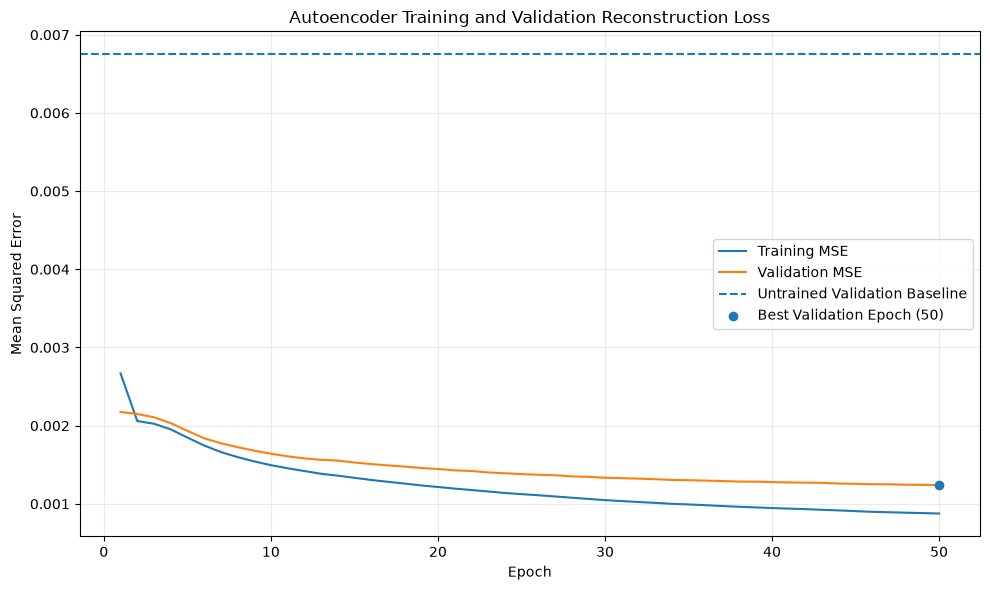

TRAINING CONVERGENCE SUMMARY
Epoch 1 training MSE: 0.00266906
Epoch 50 training MSE: 0.00087605

Epoch 1 validation MSE: 0.00217507
Best validation MSE: 0.00124039
Best epoch: 50

Final test MSE: 0.00118799


In [9]:
# ============================================================
# TRAINING AND VALIDATION LOSS CURVES
# ============================================================

import matplotlib.pyplot as plt


epochs = np.arange(
    1,
    EPOCHS + 1
)


plt.figure(
    figsize=(10, 6)
)

plt.plot(
    epochs,
    train_losses,
    label="Training MSE"
)

plt.plot(
    epochs,
    validation_losses,
    label="Validation MSE"
)

plt.axhline(
    y=baseline_validation_loss,
    linestyle="--",
    label="Untrained Validation Baseline"
)

plt.scatter(
    best_epoch,
    best_validation_loss,
    zorder=5,
    label=f"Best Validation Epoch ({best_epoch})"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Mean Squared Error"
)

plt.title(
    "Autoencoder Training and Validation Reconstruction Loss"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Numerical convergence summary
# ------------------------------------------------------------

print("TRAINING CONVERGENCE SUMMARY")
print("=" * 80)

print(
    "Epoch 1 training MSE:",
    f"{train_losses[0]:.8f}"
)

print(
    "Epoch 50 training MSE:",
    f"{train_losses[-1]:.8f}"
)

print(
    "\nEpoch 1 validation MSE:",
    f"{validation_losses[0]:.8f}"
)

print(
    "Best validation MSE:",
    f"{best_validation_loss:.8f}"
)

print(
    "Best epoch:",
    best_epoch
)

print(
    "\nFinal test MSE:",
    f"{final_test_loss:.8f}"
)

## 9. Semantic Preservation of the Learned Latent Representation

Low reconstruction error demonstrates that the autoencoder can approximate the original numerical vectors, but reconstruction performance alone does not establish that the learned 32-dimensional representation preserves meaningful relationships between books.

The autoencoder compresses each book from:

**200-dimensional LSA representation → 32-dimensional neural latent representation**

To evaluate the learned representation, cosine similarities between books are compared in the two spaces.

The analysis measures whether pairs of books that are relatively similar in the original LSA representation remain relatively similar after neural compression.

The evaluation uses the held-out **test set** so that semantic preservation is assessed on books that were not used to optimize the neural-network parameters.

The comparison focuses on:

- cosine similarity in the original 200-dimensional LSA space;
- cosine similarity in the learned 32-dimensional latent space;
- Spearman correlation between the two sets of pairwise similarities.

Spearman correlation is appropriate because the objective is to evaluate whether the relative ordering of book similarities is preserved rather than requiring the numerical cosine values in the two spaces to be identical.

A stronger positive correlation indicates greater preservation of the original semantic similarity structure.

In [10]:
# ============================================================
# SEMANTIC SIMILARITY PRESERVATION
# ============================================================

from scipy.stats import spearmanr


# ------------------------------------------------------------
# Generate latent representations for test books
# ------------------------------------------------------------

autoencoder.eval()

with torch.no_grad():

    test_original = X_test.to(device)

    test_latent = autoencoder.encoder(
        test_original
    )


# Move back to CPU for analysis
test_original_cpu = (
    test_original
    .cpu()
)

test_latent_cpu = (
    test_latent
    .cpu()
)


print("SEMANTIC PRESERVATION EVALUATION")
print("=" * 80)

print(
    "Original test representation:",
    test_original_cpu.shape
)

print(
    "Latent test representation:",
    test_latent_cpu.shape
)


# ------------------------------------------------------------
# Normalize vectors for cosine similarity
# ------------------------------------------------------------

original_normalized = torch.nn.functional.normalize(
    test_original_cpu,
    p=2,
    dim=1
)

latent_normalized = torch.nn.functional.normalize(
    test_latent_cpu,
    p=2,
    dim=1
)


# ------------------------------------------------------------
# Pairwise cosine similarity matrices
# ------------------------------------------------------------

original_similarity = (
    original_normalized
    @ original_normalized.T
)

latent_similarity = (
    latent_normalized
    @ latent_normalized.T
)


# ------------------------------------------------------------
# Extract upper triangle only
# Avoid diagonal/self-similarity and duplicate pairs
# ------------------------------------------------------------

upper_triangle = torch.triu_indices(
    row=len(X_test),
    col=len(X_test),
    offset=1
)

original_pairwise = original_similarity[
    upper_triangle[0],
    upper_triangle[1]
].numpy()

latent_pairwise = latent_similarity[
    upper_triangle[0],
    upper_triangle[1]
].numpy()


# ------------------------------------------------------------
# Spearman rank correlation
# ------------------------------------------------------------

similarity_rho, similarity_p = spearmanr(
    original_pairwise,
    latent_pairwise
)


print(
    "\nUnique book pairs evaluated:",
    len(original_pairwise)
)

print(
    "\nOriginal similarity mean:",
    f"{original_pairwise.mean():.6f}"
)

print(
    "Latent similarity mean:",
    f"{latent_pairwise.mean():.6f}"
)

print(
    "\nSpearman correlation:",
    f"{similarity_rho:.6f}"
)

print(
    "Spearman p-value:",
    f"{similarity_p:.6e}"
)

print(
    "\nAll original similarities finite:",
    bool(
        np.isfinite(
            original_pairwise
        ).all()
    )
)

print(
    "All latent similarities finite:",
    bool(
        np.isfinite(
            latent_pairwise
        ).all()
    )
)

SEMANTIC PRESERVATION EVALUATION
Original test representation: torch.Size([306, 200])
Latent test representation: torch.Size([306, 32])

Unique book pairs evaluated: 46665

Original similarity mean: 0.021400
Latent similarity mean: 0.389989

Spearman correlation: 0.107467
Spearman p-value: 6.745561e-120

All original similarities finite: True
All latent similarities finite: True


## 10. Top-10 Nearest-Neighbor Preservation

Pairwise similarity correlation evaluates the global relationship between the original and learned similarity spaces.

For a recommendation system, however, the preservation of **nearest neighbors** is particularly important.

A book recommendation system is primarily concerned with which books appear among the most similar items rather than whether every pairwise similarity value in the catalog is preserved.

This section therefore compares the **Top-10 nearest neighbors** of each held-out test book in:

1. the original 200-dimensional LSA space; and
2. the learned 32-dimensional autoencoder latent space.

For each test book, the overlap between the two Top-10 neighbor sets is calculated.

The principal measure is:

**Top-10 Neighbor Preservation = Shared Top-10 Neighbors / 10**

For example:

- `1.00` means all 10 original neighbors were preserved;
- `0.50` means 5 of 10 were preserved;
- `0.00` means none were preserved.

This provides a recommendation-oriented evaluation of whether the neural compression retains local semantic neighborhoods.

In [11]:
# ============================================================
# TOP-10 NEAREST-NEIGHBOR PRESERVATION
# ============================================================

TOP_K = 10


# ------------------------------------------------------------
# Remove self-similarity
# ------------------------------------------------------------

original_similarity_neighbors = (
    original_similarity.clone()
)

latent_similarity_neighbors = (
    latent_similarity.clone()
)

original_similarity_neighbors.fill_diagonal_(
    float("-inf")
)

latent_similarity_neighbors.fill_diagonal_(
    float("-inf")
)


# ------------------------------------------------------------
# Extract Top-K neighbors
# ------------------------------------------------------------

original_topk = torch.topk(
    original_similarity_neighbors,
    k=TOP_K,
    dim=1
).indices

latent_topk = torch.topk(
    latent_similarity_neighbors,
    k=TOP_K,
    dim=1
).indices


# ------------------------------------------------------------
# Calculate overlap for each test book
# ------------------------------------------------------------

shared_neighbor_counts = []

for row in range(
    len(X_test)
):

    original_neighbors = set(
        original_topk[row].tolist()
    )

    latent_neighbors = set(
        latent_topk[row].tolist()
    )

    shared_count = len(
        original_neighbors
        & latent_neighbors
    )

    shared_neighbor_counts.append(
        shared_count
    )


shared_neighbor_counts = np.array(
    shared_neighbor_counts
)

neighbor_preservation = (
    shared_neighbor_counts
    / TOP_K
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("TOP-10 NEAREST-NEIGHBOR PRESERVATION")
print("=" * 80)

print(
    "Test books evaluated:",
    len(neighbor_preservation)
)

print(
    "Neighbors per book:",
    TOP_K
)

print(
    "\nMean shared neighbors:",
    f"{shared_neighbor_counts.mean():.4f}"
)

print(
    "Median shared neighbors:",
    f"{np.median(shared_neighbor_counts):.1f}"
)

print(
    "\nMean Top-10 preservation:",
    f"{neighbor_preservation.mean():.4f}"
)

print(
    "Median Top-10 preservation:",
    f"{np.median(neighbor_preservation):.4f}"
)

print(
    "\nMinimum shared neighbors:",
    shared_neighbor_counts.min()
)

print(
    "Maximum shared neighbors:",
    shared_neighbor_counts.max()
)


# ------------------------------------------------------------
# Distribution
# ------------------------------------------------------------

preservation_distribution = pd.Series(
    shared_neighbor_counts
).value_counts().sort_index()

print(
    "\nShared-neighbor distribution:"
)

for shared_count, frequency in (
    preservation_distribution.items()
):

    print(
        f"{shared_count:>2} shared: "
        f"{frequency:>3} books "
        f"({frequency / len(X_test):.2%})"
    )

TOP-10 NEAREST-NEIGHBOR PRESERVATION
Test books evaluated: 306
Neighbors per book: 10

Mean shared neighbors: 4.2745
Median shared neighbors: 4.0

Mean Top-10 preservation: 0.4275
Median Top-10 preservation: 0.4000

Minimum shared neighbors: 0
Maximum shared neighbors: 9

Shared-neighbor distribution:
 0 shared:  16 books (5.23%)
 1 shared:  33 books (10.78%)
 2 shared:  52 books (16.99%)
 3 shared:  40 books (13.07%)
 4 shared:  32 books (10.46%)
 5 shared:  24 books (7.84%)
 6 shared:  23 books (7.52%)
 7 shared:  39 books (12.75%)
 8 shared:  31 books (10.13%)
 9 shared:  16 books (5.23%)


## 11. Save Neural Network Artifacts

The trained autoencoder and its evaluation outputs are saved to preserve the neural-network experiment for subsequent analysis and reproducibility.

The saved artifacts include:

1. **Autoencoder model checkpoint** — trained parameters and architecture configuration;
2. **32-dimensional latent book representations** — neural embeddings for all 2,040 eligible books;
3. **Book-to-latent-row mapping** — preserves the relationship between embeddings and book identifiers;
4. **Training history** — training and validation reconstruction loss by epoch;
5. **Model evaluation summary** — reconstruction and semantic-preservation metrics.

The 27 zero-vector books are not assigned artificial neural embeddings. They remain represented in the original catalog but are excluded from the autoencoder modelling population.

### Model Selection

Although the autoencoder achieved strong reconstruction performance, the learned 32-dimensional representation did not fully preserve the semantic geometry of the original 200-dimensional LSA space.

Therefore, the autoencoder is retained as an **experimental representation-learning model** rather than replacing the validated recommendation engine.

The production recommendation architecture remains:

**Enriched TF-IDF → Cosine Similarity → Duplicate Suppression → Ranked Top-N Recommendations**

In [12]:
# ============================================================
# SAVE AUTOENCODER AND EVALUATION ARTIFACTS
# ============================================================

AUTOENCODER_PATH = (
    MODELS_DIR
    / "book_autoencoder_200_32.pt"
)

LATENT_PATH = (
    PROCESSED_DIR
    / "autoencoder_latent_32.csv"
)

HISTORY_PATH = (
    PROCESSED_DIR
    / "autoencoder_training_history.csv"
)

EVALUATION_PATH = (
    PROCESSED_DIR
    / "autoencoder_evaluation_summary.csv"
)

SPLIT_PATH = (
    PROCESSED_DIR
    / "autoencoder_data_split.csv"
)


# ------------------------------------------------------------
# 1. Save model checkpoint
# ------------------------------------------------------------

checkpoint = {
    "model_state_dict": {
        key: value.detach().cpu()
        for key, value
        in autoencoder.state_dict().items()
    },
    "input_dim": 200,
    "latent_dim": 32,
    "learning_rate": LEARNING_RATE,
    "epochs": EPOCHS,
    "best_epoch": best_epoch,
    "best_validation_loss": best_validation_loss,
    "seed": SEED
}

torch.save(
    checkpoint,
    AUTOENCODER_PATH
)


# ------------------------------------------------------------
# 2. Generate latent vectors for all eligible books
# ------------------------------------------------------------

autoencoder.eval()

with torch.no_grad():

    all_latent = autoencoder.encoder(
        model_feature_tensor.to(device)
    ).cpu()


latent_columns = [
    f"AE_{i:02d}"
    for i in range(
        1,
        all_latent.shape[1] + 1
    )
]

latent_df = pd.DataFrame(
    all_latent.numpy(),
    columns=latent_columns
)

latent_df.insert(
    0,
    "book_id",
    model_book_ids
)

latent_df.to_csv(
    LATENT_PATH,
    index=False
)


# ------------------------------------------------------------
# 3. Save training history
# ------------------------------------------------------------

training_history = pd.DataFrame({
    "epoch": np.arange(
        1,
        EPOCHS + 1
    ),
    "training_mse": train_losses,
    "validation_mse": validation_losses
})

training_history.to_csv(
    HISTORY_PATH,
    index=False
)


# ------------------------------------------------------------
# 4. Save evaluation summary
# ------------------------------------------------------------

evaluation_summary = pd.DataFrame({
    "metric": [
        "untrained_validation_mse",
        "best_validation_mse",
        "untrained_test_mse",
        "final_test_mse",
        "test_mse_improvement_pct",
        "pairwise_similarity_spearman_rho",
        "pairwise_similarity_spearman_p",
        "mean_top10_shared_neighbors",
        "median_top10_shared_neighbors",
        "mean_top10_neighbor_preservation",
        "median_top10_neighbor_preservation"
    ],

    "value": [
        baseline_validation_loss,
        final_validation_loss,
        baseline_test_loss,
        final_test_loss,
        test_improvement,
        similarity_rho,
        similarity_p,
        shared_neighbor_counts.mean(),
        np.median(shared_neighbor_counts),
        neighbor_preservation.mean(),
        np.median(neighbor_preservation)
    ]
})

evaluation_summary.to_csv(
    EVALUATION_PATH,
    index=False
)


# ------------------------------------------------------------
# 5. Save data split membership
# ------------------------------------------------------------

split_df = pd.concat(
    [
        pd.DataFrame({
            "book_id": train_book_ids,
            "split": "train"
        }),

        pd.DataFrame({
            "book_id": validation_book_ids,
            "split": "validation"
        }),

        pd.DataFrame({
            "book_id": test_book_ids,
            "split": "test"
        })
    ],
    ignore_index=True
)

split_df.to_csv(
    SPLIT_PATH,
    index=False
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

print("AUTOENCODER ARTIFACT VALIDATION")
print("=" * 80)

print(
    "Model checkpoint:",
    AUTOENCODER_PATH.exists()
)

print(
    "Latent representations:",
    LATENT_PATH.exists()
)

print(
    "Training history:",
    HISTORY_PATH.exists()
)

print(
    "Evaluation summary:",
    EVALUATION_PATH.exists()
)

print(
    "Data split:",
    SPLIT_PATH.exists()
)

print(
    "\nLatent shape:",
    latent_df.shape
)

print(
    "Expected latent dimensions:",
    len(latent_columns)
)

print(
    "Unique latent book IDs:",
    latent_df["book_id"].nunique()
)

print(
    "\nSplit rows:",
    len(split_df)
)

print(
    "Unique split book IDs:",
    split_df["book_id"].nunique()
)

print(
    "\nTraining history rows:",
    len(training_history)
)

print(
    "Evaluation metrics:",
    len(evaluation_summary)
)

print("\nSaved artifacts:")
print(AUTOENCODER_PATH)
print(LATENT_PATH)
print(HISTORY_PATH)
print(EVALUATION_PATH)
print(SPLIT_PATH)

AUTOENCODER ARTIFACT VALIDATION
Model checkpoint: True
Latent representations: True
Training history: True
Evaluation summary: True
Data split: True

Latent shape: (2040, 33)
Expected latent dimensions: 32
Unique latent book IDs: 2040

Split rows: 2040
Unique split book IDs: 2040

Training history rows: 50
Evaluation metrics: 11

Saved artifacts:
/Users/jannoelvero/Documents/Ironhack/Week_11/Leadership_Management_Book_Recommendation_System/models/book_autoencoder_200_32.pt
/Users/jannoelvero/Documents/Ironhack/Week_11/Leadership_Management_Book_Recommendation_System/data/processed/autoencoder_latent_32.csv
/Users/jannoelvero/Documents/Ironhack/Week_11/Leadership_Management_Book_Recommendation_System/data/processed/autoencoder_training_history.csv
/Users/jannoelvero/Documents/Ironhack/Week_11/Leadership_Management_Book_Recommendation_System/data/processed/autoencoder_evaluation_summary.csv
/Users/jannoelvero/Documents/Ironhack/Week_11/Leadership_Management_Book_Recommendation_System/dat

# Notebook 14 — Simple Neural Network: Final Summary

## Objective

This notebook evaluated whether a simple feed-forward neural network could learn a compact representation of the book-level semantic features developed earlier in the project.

Because the project does not contain a genuine supervised target variable, no artificial classification or regression target was created.

Instead, an **unsupervised autoencoder** was implemented to compress and reconstruct the existing 200-dimensional LSA book representations.

---

## Modelling Population

The original PyTorch representation contained:

- **2,067 books**
- **200 LSA features**
- **27 zero-vector books**

The 27 zero-vector observations were preserved in the complete catalog but excluded from neural-network training because they contain no usable semantic information.

Final neural-network modelling population:

**2,040 books × 200 features**

No missing or infinite numerical values were present.

---

## Data Partitioning

The 2,040 eligible books were divided reproducibly using a fixed random seed:

| Partition | Books | Share |
|---|---:|---:|
| Training | 1,428 | 70% |
| Validation | 306 | 15% |
| Test | 306 | 15% |
| **Total** | **2,040** | **100%** |

No books overlapped between partitions.

The test partition was excluded from parameter optimization and model checkpoint selection.

---

## Autoencoder Architecture

The feed-forward autoencoder used the following architecture:

**200 → 128 → 64 → 32 → 64 → 128 → 200**

The **32-dimensional bottleneck** represents the learned neural embedding.

The model contained:

- **72,296 total parameters**
- **72,296 trainable parameters**

ReLU activation was used in the hidden layers.

The output layer remained linear because the original LSA representation contains both positive and negative values.

The model successfully operated using the Apple Metal Performance Shaders (`mps`) backend.

---

## Training

The model was trained for **50 epochs** using:

- Loss function: **Mean Squared Error (MSE)**
- Optimizer: **Adam**
- Learning rate: **0.001**
- Batch size: **32**

Training and validation reconstruction loss decreased throughout the experiment.

The lowest validation loss occurred at:

**Epoch 50**

No validation-loss reversal was observed within the tested 50 epochs.

---

## Reconstruction Performance

### Untrained Baseline

- Validation MSE: **0.00675031**
- Test MSE: **0.00669216**

### Trained Model

- Training MSE: **0.00085461**
- Validation MSE: **0.00124039**
- Test MSE: **0.00118799**

The final test reconstruction error was approximately **82.25% lower** than the untrained test baseline.

The test MSE was close to the validation MSE, providing evidence that the reconstruction performance generalized to the held-out test books.

These results demonstrate that the autoencoder successfully learned to reconstruct the 200-dimensional LSA representations.

---

## Semantic Similarity Preservation

Low reconstruction error does not necessarily mean that the learned representation preserves the semantic geometry required for recommendation.

The original 200-dimensional LSA similarities were therefore compared with similarities calculated from the learned 32-dimensional latent representation.

Using **46,665 unique pairs of held-out test books**:

- Mean original LSA cosine similarity: **0.021400**
- Mean latent cosine similarity: **0.389989**
- Spearman correlation: **ρ = 0.107467**
- p-value: **6.75 × 10⁻¹²⁰**

The association is statistically detectable but weak in magnitude.

The very small p-value should not be interpreted as evidence of strong semantic preservation. With 46,665 book pairs, even a relatively small association can be statistically significant.

The substantial increase in mean cosine similarity also indicates that the learned latent space is more compressed geometrically than the original LSA space.

---

## Top-10 Neighbor Preservation

Because recommendation systems depend heavily on local nearest-neighbor relationships, Top-10 neighbor preservation was evaluated separately.

Results:

- Mean shared Top-10 neighbors: **4.27 of 10**
- Median shared neighbors: **4 of 10**
- Mean Top-10 preservation: **42.75%**
- Median Top-10 preservation: **40.00%**
- Minimum shared neighbors: **0**
- Maximum shared neighbors: **9**

For **5.23% of test books**, none of the original Top-10 LSA neighbors appeared among the Top-10 neighbors in the neural latent space.

Other books retained substantially more of their original neighborhoods, demonstrating that preservation varies across the catalog.

---

## Statistical Significance vs. Practical Usefulness

The experiment demonstrates an important distinction between three concepts:

### 1. Reconstruction Quality

The autoencoder achieved strong reconstruction performance.

**Test MSE improvement: 82.25%**

### 2. Statistical Association

Original and latent similarities were positively associated and statistically significant.

**Spearman ρ = 0.107467**

However, the effect size was weak.

### 3. Recommendation Usefulness

The learned 32-dimensional representation preserved approximately:

**42.75% of Top-10 LSA neighbors on average**

Therefore, successful reconstruction and statistical significance do not automatically imply that a learned representation is preferable for recommendation.

---

## Model Decision

The autoencoder is retained as a successful **neural representation-learning experiment**, but the 32-dimensional latent representation is **not adopted as the primary recommendation representation**.

The evidence shows:

**Strong reconstruction performance**

but

**limited preservation of the original semantic similarity structure.**

Accordingly, the validated production recommendation architecture remains:

**Enriched TF-IDF → Cosine Similarity → Duplicate Suppression → Ranked Top-N Recommendations**

The neural-network model supplements the analysis rather than replacing the existing recommendation engine.

This decision is based on empirical evaluation rather than assuming that a more complex neural model must outperform the simpler content-based approach.

---

## Saved Artifacts

### Model

`models/book_autoencoder_200_32.pt`

### Neural Embeddings

`data/processed/autoencoder_latent_32.csv`

Contains:

- 2,040 eligible books
- 32 neural latent dimensions
- book identifier

### Training History

`data/processed/autoencoder_training_history.csv`

Contains training and validation MSE across all 50 epochs.

### Evaluation Summary

`data/processed/autoencoder_evaluation_summary.csv`

Contains reconstruction and semantic-preservation metrics.

### Data Split

`data/processed/autoencoder_data_split.csv`

Preserves the train, validation, and test membership of all 2,040 eligible books.

---

## Final Status

**Notebook 14 — Simple Neural Network: COMPLETE**

Final neural-network workflow:

**200-D LSA → PyTorch Autoencoder → 32-D Latent Representation → Reconstruction Evaluation → Semantic Preservation Evaluation → Top-10 Neighbor Evaluation**

### Final Finding

The autoencoder successfully compressed and reconstructed the numerical book representations, but the learned 32-dimensional embedding did not preserve enough of the original semantic neighborhood structure to justify replacing the validated TF-IDF recommendation engine.

The experiment therefore provides both a technically successful neural-network implementation and an evidence-based model-selection decision.